<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/santi/RA1_TP4/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_4_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TP4 - Aprendizaje no supervisado

In [129]:
# @title *Esta celda importa utilidades comunes al colab*
import sys
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time
import warnings
from scipy.stats import norm, ks_2samp
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import classification_report, mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score, silhouette_score, davies_bouldin_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

#Ejercicio 2 - Detección de fraude en transacciones bancarias

>Una fintech que opera un sistema de pagos automatizado con tarjetas de crédito procesa en promedio
300.000 transacciones diarias. El sistema aprueba las operaciones en tiempo real: una demora de más de
2 segundos en la decisión es inaceptable desde el punto de vista de experiencia del usuario.
El equipo de riesgo realizó hace varios meses un estudio interno sobre una muestra de transacciones y
determinó que menos del 0,2 % corresponden a operaciones fraudulentas o sospechosas. Sin embargo,
ese estudio tiene limitaciones metodológicas que no son del todo claras, y el equipo no confía
completamente en ese porcentaje. Las operaciones sospechosas deberían retenerse para revisión manual
antes de ser aprobadas, pero el costo de retener una operación legítima (cliente insatisfecho, fricción)
también es real.
El dataset [2] (creditcard.csv) contiene más de 280.000 transacciones con las siguientes variables: Time
(segundos desde la primera transacción del conjunto), V1 a V28 (características de la operación,
probablemente resultado de una reducción de dimensionalidad previa por razones de confidencialidad),
y Amount (monto de la transacción). No se proveen etiquetas de fraude: el ejercicio consiste en encontrar
las anomalías de forma no supervisada.



---


## 0. Configuración del entorno

In [91]:
# Dataset desde el repositorio en Drive
# A partir de cierto tamaño, no se puede descargar directo con wget

import gdown
file_id = "1Zy1fV1U5nXj8XXhcqEI4YjEmlzbodk0n"
output_file = "creditcard.zip"

if not os.path.exists(output_file):
    gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file)
    !unzip creditcard.zip

df_fraude = pd.read_csv("creditcard.csv")
# El dataset real tiene columna 'Class'; la removemos para el ejercicio no supervisado
# pero la guardamos para evaluación posterior si existe
if "Class" in df_fraude.columns:
    TRUE_LABELS = df_fraude["Class"].copy()
    df_fraude.drop(columns=["Class"], inplace=True)
    HAS_TRUE_LABELS = True
    print(f"Dataset real cargado: {df_fraude.shape[0]:,} filas × {df_fraude.shape[1]} columnas")
    print(f"Etiquetas reales disponibles para evaluación (no usadas en modelado)")

Dataset real cargado: 284,807 filas × 30 columnas
Etiquetas reales disponibles para evaluación (no usadas en modelado)




---


##1. EDA

### 1.1 Vistazo inicial

Comenzamos dando una pequeña vista a algunas entradas de nuestro dataset.

Entre las variables contamos con `Time` y `Amount` por un lado y las variables `V1 - V28`, siendo estas ultimas resultado de una reduccion de dimensionalidad previa.

In [ ]:

# Resumen general
print("=" * 60)
print("RESUMEN GENERAL DEL DATASET")
print("=" * 60)
print(f"Dimensiones        : {df_fraude.shape[0]:,} filas × {df_fraude.shape[1]} columnas")
print(f"Memoria estimada   : {df_fraude.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Valores faltantes  : {df_fraude.isnull().sum().sum()}")
print()
display(df_fraude.head())


RESUMEN GENERAL DEL DATASET
Dimensiones        : 284,807 filas × 30 columnas
Memoria estimada   : 68.4 MB
Valores faltantes  : 0



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [ ]:
# Verificar si hay valores negativos en 'Time' y 'Amount'
negativos_time = (df_fraude['Time'] < 0).sum()
negativos_amount = (df_fraude['Amount'] < 0).sum()

print(f"Valores negativos en 'Time': {negativos_time}")
print(f"Valores negativos en 'Amount': {negativos_amount}")

if negativos_time == 0 and negativos_amount == 0:
    print("\nNo se encontraron valores negativos en estas columnas.")
else:
    print("\nSe detectaron valores negativos que requieren revisión.")

Valores negativos en 'Time': 0
Valores negativos en 'Amount': 0

No se encontraron valores negativos en estas columnas.


El dataset no presenta valores faltantes o ilógicos, lo que elimina la necesidad de
imputación y descarta que los NaN sean una señal espuria de anomalía.

Las 30 columnas corresponden a Time, V1–V28 y Amount. La columna `Class`
fue removida antes del análisis confirmando que el ejercicio es genuinamente
no supervisado: los modelos no tienen acceso a ninguna etiqueta durante
el entrenamiento.

Con 284.807 filas y 68.4 MB el dataset es manejable en memoria, pero su
tamaño descarta métodos con complejidad cuadrática como One-Class SVM,
cuya matriz de Gram requeriría varios cientos de GB solo para almacenarse.

### 1.2 Estadística descriptiva

La tabla de estadísticas descriptivas se extiende con dos métricas adicionales
que son especialmente relevantes para detección de anomalías: asimetría y curtosis.

**Asimetría (skewness)** indica si la distribución tiene una cola más larga hacia
alguno de los dos lados. Una variable muy sesgada hace que modelos como PCA de
reconstrucción capturen la asimetría como si fuera estructura relevante, cuando
en realidad es una característica distribucional de las transacciones legítimas.

**Curtosis (kurtosis)** mide qué tan pesadas son las colas respecto a una
distribución normal. Una curtosis alta significa más valores extremos de lo
esperado, lo que afecta directamente la calibración del umbral de detección:
si todas las variables tienen colas pesadas, un umbral fijo basado en normalidad
va a generar demasiados falsos positivos.

In [ ]:

# Estadísticas descriptivas
desc = df_fraude.describe().T
desc["skewness"] = df_fraude.skew()
desc["kurtosis"] = df_fraude.kurt()
display(desc.round(3))


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Time,284807.0,94813.86,47488.146,0.000,54201.500,84692.000,139320.500,172792.000,-0.036,-1.294
V1,284807.0,0.00,1.959,-56.408,-0.920,0.018,1.316,2.455,-3.281,32.487
V2,284807.0,0.00,1.651,-72.716,-0.599,0.065,0.804,22.058,-4.625,95.773
V3,284807.0,-0.00,1.516,-48.326,-0.890,0.180,1.027,9.383,-2.240,26.620
V4,284807.0,0.00,1.416,-5.683,-0.849,-0.020,0.743,16.875,0.676,2.635
V5,284807.0,0.00,1.380,-113.743,-0.692,-0.054,0.612,34.802,-2.426,206.905
V6,284807.0,0.00,1.332,-26.161,-0.768,-0.274,0.399,73.302,1.827,42.642
V7,284807.0,-0.00,1.237,-43.557,-0.554,0.040,0.570,120.589,2.554,405.607
V8,284807.0,0.00,1.194,-73.217,-0.209,0.022,0.327,20.007,-8.522,220.587
V9,284807.0,-0.00,1.099,-13.434,-0.643,-0.051,0.597,15.595,0.555,3.731


Analizando estos datos, notamos un común denominador en algunas variables, y es su alto valor de curtosis. Una curtosis alta significa que hay más valores extremos de lo esperado.  
En cuanto al sesgo de las variables, la mayoria parecen apuntar a la simetría, siendo la mas sesgada `Amount`.

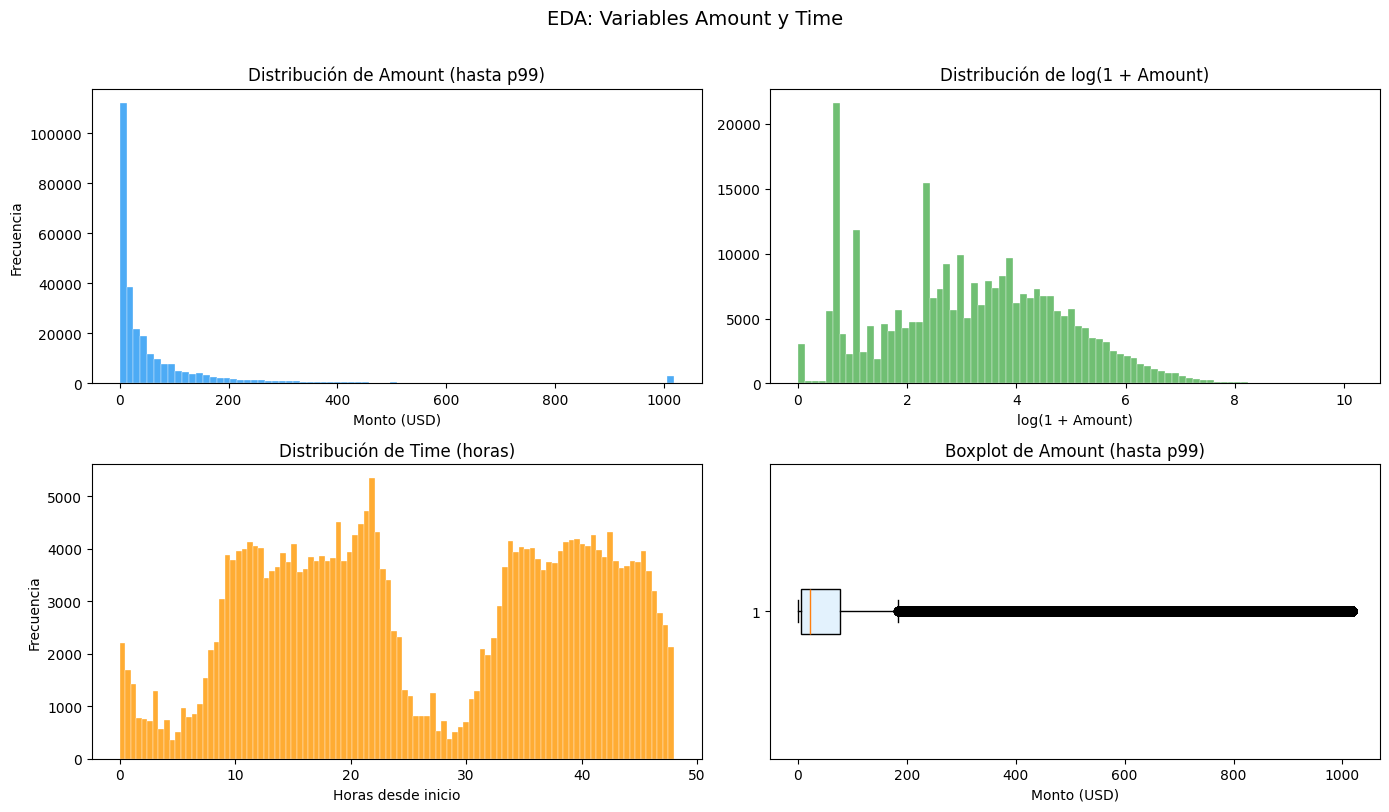

Amount — Mediana: $22.00  |  Media: $88.35
Amount — p95: $365.00  |  p99: $1017.97  |  Máx: $25691.16
Time   — Rango: 0s – 172792s (48.0 horas)


In [ ]:

# Distribución de Amount y Time
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Amount
ax = axes[0, 0]
ax.hist(df_fraude["Amount"].clip(upper=df_fraude["Amount"].quantile(0.99)),
        bins=80, color="#2196F3", alpha=0.8, edgecolor="white", linewidth=0.3)
ax.set_title("Distribución de Amount (hasta p99)")
ax.set_xlabel("Monto (USD)")
ax.set_ylabel("Frecuencia")

# Log Amount
ax = axes[0, 1]
ax.hist(np.log1p(df_fraude["Amount"]), bins=80, color="#4CAF50", alpha=0.8,
        edgecolor="white", linewidth=0.3)
ax.set_title("Distribución de log(1 + Amount)")
ax.set_xlabel("log(1 + Amount)")

# Time
ax = axes[1, 0]
ax.hist(df_fraude["Time"] / 3600, bins=100, color="#FF9800", alpha=0.8,
        edgecolor="white", linewidth=0.3)
ax.set_title("Distribución de Time (horas)")
ax.set_xlabel("Horas desde inicio")
ax.set_ylabel("Frecuencia")

# Boxplot de Amount
ax = axes[1, 1]
data_box = df_fraude["Amount"].clip(upper=df_fraude["Amount"].quantile(0.99))
ax.boxplot(data_box, vert=False, patch_artist=True,
           boxprops=dict(facecolor="#E3F2FD"))
ax.set_title("Boxplot de Amount (hasta p99)")
ax.set_xlabel("Monto (USD)")

plt.suptitle("EDA: Variables Amount y Time", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Amount — Mediana: ${df_fraude['Amount'].median():.2f}  |  Media: ${df_fraude['Amount'].mean():.2f}")
print(f"Amount — p95: ${df_fraude['Amount'].quantile(0.95):.2f}  |  p99: ${df_fraude['Amount'].quantile(0.99):.2f}  |  Máx: ${df_fraude['Amount'].max():.2f}")
print(f"Time   — Rango: {df_fraude['Time'].min():.0f}s – {df_fraude['Time'].max():.0f}s ({df_fraude['Time'].max()/3600:.1f} horas)")


Aqui podemos ver la distribución real de `Monto` excluyendo el 1% más extremo para que la escala no aplaste el resto, confirmando su alto sesgo positivo.  
Ademas, al aplicar una transformacion logarítmica se produce una distribución aproximadamente simétrica y unimodal, demostrando que sigue una distribución log-normal.

Al mismo tiempo, notamos que en la distribución de `Time` se pueden distinguir dos ciclos de 24 horas, con valles pronunciados en ciertos valores (probablemente altas horas de la noche).  

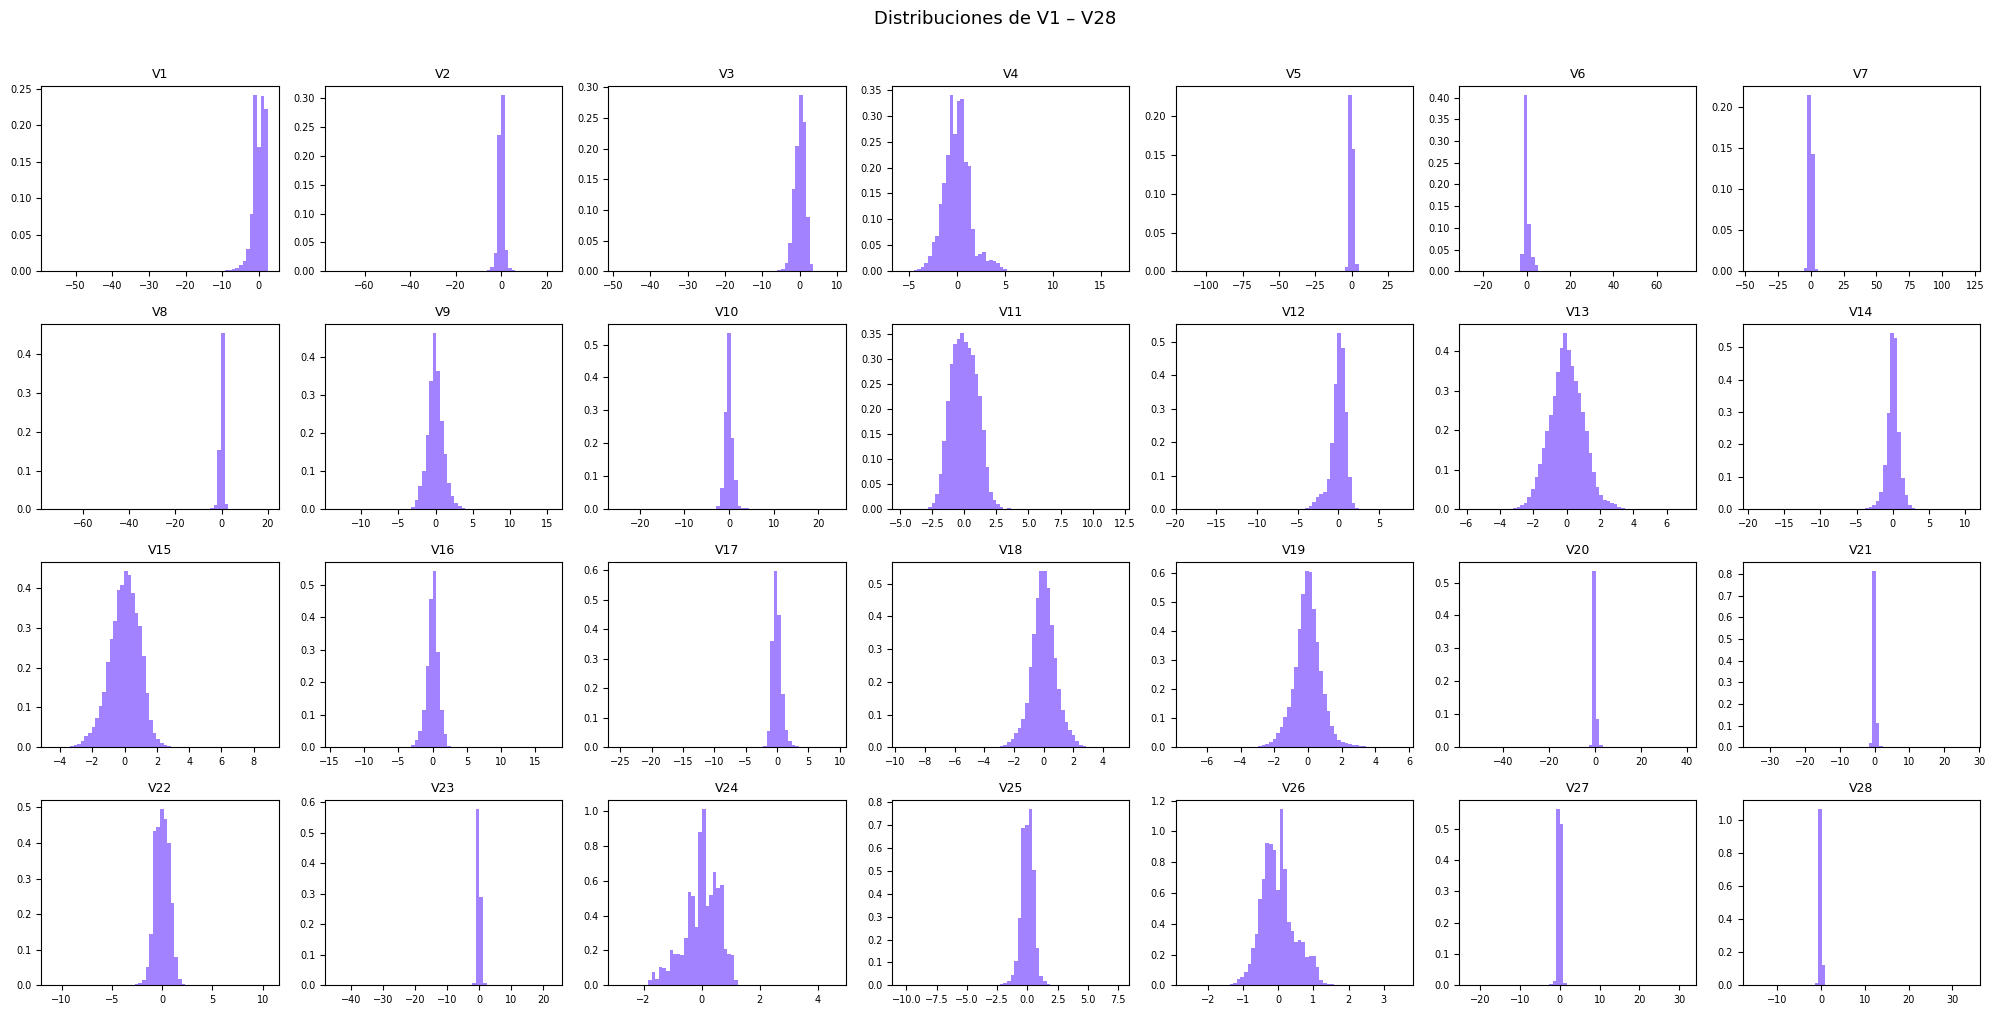


Top 10 variables por asimetría absoluta:


,Variable,Skewness,Kurtosis
0,Amount,16.977724,845.092646
1,V28,11.192091,933.397502
2,V8,-8.521944,220.586974
3,V23,-5.875140,440.088659
4,V2,-4.624866,95.773106
5,V17,-3.844914,94.799719
6,V21,3.592991,207.287040
7,V1,-3.280667,32.486679
8,V7,2.553907,405.607417
9,V5,-2.425901,206.904560


In [ ]:
# Distribuciones de variables V1-V28
v_cols = [f"V{i}" for i in range(1, 29)]

fig, axes = plt.subplots(4, 7, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(v_cols):
    axes[i].hist(df_fraude[col], bins=60, color="#7C4DFF", alpha=0.7,
                 edgecolor="none", density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

# Ocultar subplots sobrantes
for j in range(len(v_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribuciones de V1 – V28", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Asimetría
skew_df_fraude = pd.DataFrame({
    "Variable": v_cols + ["Amount"],
    "Skewness": [df_fraude[c].skew() for c in v_cols] + [df_fraude["Amount"].skew()],
    "Kurtosis": [df_fraude[c].kurt() for c in v_cols] + [df_fraude["Amount"].kurt()],
}).sort_values("Skewness", key=abs, ascending=False)

print("\nTop 10 variables por asimetría absoluta:")
display(skew_df_fraude.head(10).reset_index(drop=True))

La mayoría de las variables están centradas en cero y tienen forma
aproximadamente simétrica, lo cual es consistente con el PCA previo
y es una buena señal para el modelado.  
Las excepciones son las variables del top de asimetría absoluta, que pueden
distorsionar el modelo de reconstrucción PCA al capturar sus colas como
estructura relevante. Las de curtosis elevada pueden generar falsos positivos
en Isolation Forest al confundir valores extremos legítimos con anomalías.

### 1.3 Correlaciones

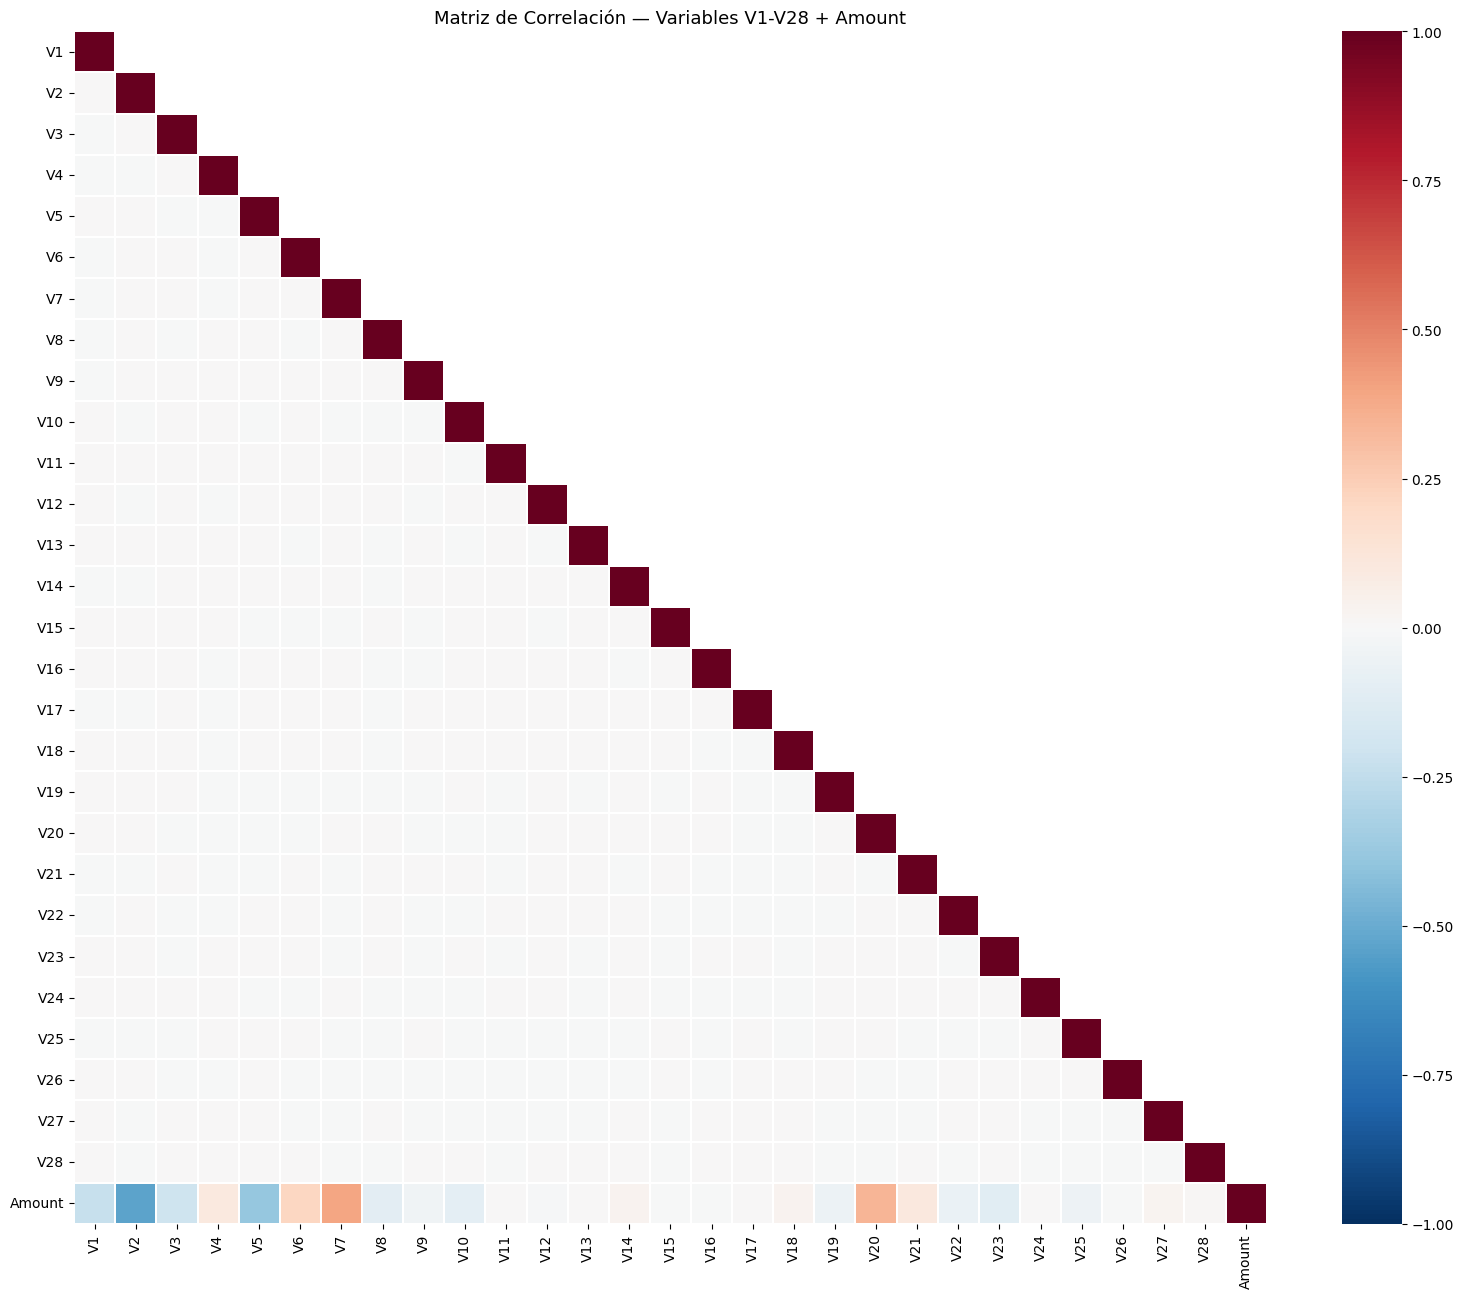

Pares con |correlación| > 0.15:
V2   Amount   -0.531409
V7   Amount    0.397311
V5   Amount   -0.386356
V20  Amount    0.339403
V1   Amount   -0.227709
V6   Amount    0.215981
V3   Amount   -0.210880


In [ ]:

# Mapa de correlaciones
fig, ax = plt.subplots(figsize=(16, 13))

corr = df_fraude[v_cols + ["Amount"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.3, linecolor="white",
            annot=False, ax=ax, square=True)

ax.set_title("Matriz de Correlación — Variables V1-V28 + Amount", fontsize=13)
plt.tight_layout()
plt.show()

# Pares más correlacionados
corr_unstacked = corr.where(~np.tril(np.ones(corr.shape, dtype=bool))).stack()
print("Pares con |correlación| > 0.15:")
high_corr = corr_unstacked[corr_unstacked.abs() > 0.15].sort_values(key=abs, ascending=False)
print(high_corr.head(15).to_string())


Las correlaciones entre V1–V28 son cercanas a cero, confirmando que el
PCA previo fue aplicado correctamente y que no hay redundancia entre variables.

Las correlaciones con Amount son en general bajas, lo que indica que el
monto de la transacción no está capturado dominantemente por ninguna
componente individual. Esto es relevante para el modelado: Amount aporta
información independiente de las V y su inclusión como feature adicional
está justificada.

### 1.4 Deteccion de valores extremos

Decidimos utilizar las métricas z-score e IQR para detectar valores extremos porque:

- El z-score es sensible a los propios outliers que intenta detectar, un valor extremo desplaza la media y el desvío, lo que puede tanto inflar como ocultar otros outliers.
- El IQR usa solo la mitad central de los datos como referencia, por lo que es robusto a ese efecto. Usar ambos juntos permite detectar **discrepancias entre métodos**, que son en sí mismas información sobre la forma de cada distribución.

In [ ]:

# Detección de outliers univariados (z-score y IQR)
from scipy.stats import zscore

v_cols = [f"V{i}" for i in range(1, 29)]
z_scores = df_fraude[v_cols + ["Amount"]].apply(zscore)
outliers_z = (z_scores.abs() > 3).sum()

q1 = df_fraude[v_cols + ["Amount"]].quantile(0.25)
q3 = df_fraude[v_cols + ["Amount"]].quantile(0.75)
iqr = q3 - q1
outliers_iqr = ((df_fraude[v_cols + ["Amount"]] < (q1 - 3 * iqr)) |
                (df_fraude[v_cols + ["Amount"]] > (q3 + 3 * iqr))).sum()

out_df = pd.DataFrame({
    "Outliers |z| > 3": outliers_z,
    "Outliers IQR×3":   outliers_iqr,
})
out_df["% z-score"] = (out_df["Outliers |z| > 3"] / len(df_fraude) * 100).round(3)
out_df["% IQR"]     = (out_df["Outliers IQR×3"]   / len(df_fraude) * 100).round(3)
print("Outliers univariados por variable:")
display(out_df.sort_values("% z-score", ascending=False).head(15))

Outliers univariados por variable:


,Outliers |z| > 3,Outliers IQR×3,% z-score,% IQR
V27,4771,16524,1.675,5.802
V6,4652,5389,1.633,1.892
V20,4645,13385,1.631,4.700
V2,4318,4453,1.516,1.564
V8,4221,11285,1.482,3.962
Amount,4076,18941,1.431,6.650
V21,4064,6934,1.427,2.435
V1,3701,1994,1.299,0.700
V10,3488,3208,1.225,1.126
V7,3401,3051,1.194,1.071


### Conclusiones del análisis de outliers univariados

**1. Las discrepancias entre métodos son la señal más relevante**  
Variables como V19 (z-score: 1,19% vs IQR: 0,22%) y Amount (z-score: 1,43% vs IQR: 6,65%) muestran diferencias de 5 a 6 veces entre métodos. Esto indica distribuciones fuertemente sesgadas donde el z-score está siendo engañado por la media desplazada. Estas variables requieren transformación (log, RobustScaler) antes del modelado con PCA.

**2. V1 es el caso opuesto**  
Z-score detecta más que IQR (1,30% vs 0,70%), lo que sugiere una distribución
simétrica pero con colas más pesadas que una normal (alta curtosis).
Los outliers de V1 son genuinamente extremos en ambas direcciones.

**3. El volumen general no implica fraude**  
Las variables del top tienen entre 1,1% y 1,7% de outliers univariados.
Con 28 variables, casi cualquier transacción sería outlier en alguna variable
por simple probabilidad. Esto confirma que **los outliers univariados no son anomalías**:
son condición necesaria pero no suficiente. El modelado multivariado es imprescindible.

### 1.5 Outliers y anomalias

Un outlier es una observación estadísticamente alejada de la distribución de una o pocas variables individualmente. Lo detecta el EDA con z-score o IQR, sin considerar el resto de las variables.  
Una anomalía es una observación cuyo patrón multivariado completo es improbable dado el comportamiento normal. La detectan IF, LOF y PCA considerando todas las variables simultáneamente.

Coinciden cuando el fraude se manifiesta en valores extremos de variables individuales, como un monto de 25.000 en un perfil que nunca supera 200. No coinciden cuando el fraude tiene valores normales en cada variable por separado pero la combinación es incoherente, que es exactamente el fraude sofisticado que los modelos multivariados están diseñados para detectar y que el EDA nunca vería.



---


##2. Estrategia y preprocesamiento

### 2.1 Selección de estrategias no supervisadas

### Criterios de selección

Con **~280.000 transacciones**, **28 dimensiones** y una tasa de fraude esperada de **< 0,2 %**, los criterios son:

- **Escala computacional:** el algoritmo debe entrenar sobre 280k filas
  en tiempo razonable. Métodos con complejidad O(n²) o superior quedan
  descartados directamente.
- **Latencia de inferencia:** el sistema debe decidir en menos de 2 segundos
  por transacción. El costo de entrenamiento es tolerable; el de predicción, no.
- **Desbalance extremo:** con menos del 0,2% de anomalías, los métodos que
  asumen clases balanceadas o que dependen de clusters bien definidos
  pierden capacidad discriminativa.
- **Supuestos distribucionales:** algunos métodos asumen normalidad o
  frontera hiperesferal. Dado lo que vimos en el EDA, esos supuestos
  no se sostienen en este dataset.

### Métodos evaluados

| Método | Escala | Supuesto clave | Viable en prod | Decisión |
|---|---|---|---|---|
| **Isolation Forest** | ✅ O(n log n) | Anomalías son pocas y distintas | ✅ | Incluido |
| **LOF** | ⚠️ O(n²) sin aprox. | Densidad local comparable | ⚠️ Solo batch | Incluido |
| **PCA Reconstruction** | ✅ O(n·k·d) | Varianza = comportamiento normal | ✅ | Incluido |
| **One-Class SVM** | ❌ O(n²–n³) | Frontera hiperesferal | ❌ | Descartado |
| **DBSCAN** | ⚠️ O(n log n) | Clusters densos definidos | ⚠️ | Solo exploratorio |
| **GMM** | ⚠️ O(n·k²·d²) | Normalidad en subpoblaciones | ⚠️ | Descartado |


**One-Class SVM** se descarta porque el kernel RBF requiere calcular la
matriz de Gram completa de n×n. A 280k registros eso implica almacenar
y operar sobre ~280 GB solo para la matriz, lo cual es inviable en un sistema de producción real.

**DBSCAN** se reserva para análisis exploratorio de clusters pero no
se usa como detector de anomalías porque no produce un score continuo
ni permite predecir sobre nuevas transacciones sin reentrenar.


### 2.2 Preprocesamiento

Se utiliza `RobustScaler` en lugar de `StandardScaler` porque este ultimo usa la media y el desvío estándar, ambos sensibles a valores extremos. En un dataset donde los outliers son lo que buscamos detectar, usar un scaler que se distorsiona por ellos introduciría un sesgo circular. El RobustScaler usa la mediana y el IQR, que son estadísticos robustos no afectados por los extremos, preservando la señal de anomalía en lugar de atenuarla.

In [92]:
# Aplicamos RobustScaler (resistente a outliers) sobre Amount y Time.
# V1-V28 ya están escaladas (resultado de PCA original del dataset).

features = v_cols + ["Amount", "Time"]

scaler = RobustScaler()
X = scaler.fit_transform(df_fraude[features])
X_df_fraude = pd.DataFrame(X, columns=features)

print(f"Shape de la matriz de features escalada: {X.shape}")
print(f"Media aproximada (debe ser ~0 post-scaling): {X.mean(axis=0)[:5].round(3)}")
print(f"Rango intercuartílico (debe ser ~1):         {np.percentile(X, 75, axis=0)[:5].round(3) - np.percentile(X, 25, axis=0)[:5].round(3)}")


Shape de la matriz de features escalada: (284807, 30)
Media aproximada (debe ser ~0 post-scaling): [-0.008 -0.047 -0.094  0.012  0.042]
Rango intercuartílico (debe ser ~1):         [1. 1. 1. 1. 1.]


La media post-scaling es aproximadamente cero y el rango intercuartílico
cercano a 1 en todas las variables, confirmando que el RobustScaler
funcionó correctamente.

### 2.3 Submuestreo

El dataset completo tiene 284.807 transacciones. Dado el costo computacional
de algunos modelos (especialmente LOF) y la necesidad de iterar rápidamente,
se trabaja con una muestra estratificada de 30.000 transacciones.

El muestreo se hace de forma **aleatoria sin reemplazo** para preservar la
distribución original de las variables. Se fija una semilla para garantizar
reproducibilidad. Las etiquetas reales (`TRUE_LABELS`) se submuestrean en
paralelo para poder evaluar los modelos al final sin haberlas usado durante
el entrenamiento.

In [93]:
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

N_SAMPLE = 10_000
sample_idx = np.random.choice(len(X), N_SAMPLE, replace=False)

X_sample = X[sample_idx]
labels_sample = TRUE_LABELS.values[sample_idx]

print(f"Muestra: {X_sample.shape[0]:,} transacciones × {X_sample.shape[1]} features")
print(f"Fraudes en la muestra: {labels_sample.sum():,}  ({labels_sample.mean()*100:.3f} %)")
print(f"Tasa de fraude en el dataset completo: {TRUE_LABELS.mean()*100:.3f} %")


Muestra: 10,000 transacciones × 30 features
Fraudes en la muestra: 13  (0.130 %)
Tasa de fraude en el dataset completo: 0.173 %


La tasa de fraude en la muestra debe ser cercana a la del dataset completo (~0,17%).
Una diferencia grande indicaría que el muestreo aleatorio introdujo sesgo,
lo cual comprometería la validez de los modelos entrenados sobre ella.

---

## 3. Isolation Forest

Isolation Forest detecta anomalías por **aislamiento**: construye árboles de
decisión aleatorios que particionan el espacio de features y mide cuántos
cortes se necesitan para aislar cada punto. Un punto anómalo, al estar alejado
de la masa de datos, se aísla con muy pocos cortes. Un punto normal requiere
muchos más porque está rodeado de vecinos similares.

El score de anomalía es inversamente proporcional a la profundidad promedio
de aislamiento en el bosque: **menor profundidad = mayor score = más anómalo**.

### Parámetros clave

- `n_estimators=200`: número de árboles. Más árboles mejoran la estabilidad
  del score a costa de tiempo de entrenamiento. 200 es un balance razonable.
- `contamination=0.002`: fracción esperada de anomalías. Coincide con el 0,2%
  reportado por el equipo de riesgo. Este parámetro fija el umbral del score
  a partir del cual una transacción se clasifica como anómala.
- `max_samples='auto'`: tamaño de la submuestra por árbol. En 'auto' usa
  min(256, n). Muestras pequeñas aceleran el entrenamiento y mejoran la
  capacidad de aislamiento en datasets grandes.

In [115]:
# Entrenamiento
t0 = time.time()
iforest = IsolationForest(
    n_estimators=200,
    contamination=0.002,
    max_samples="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iforest.fit(X_sample)
t_fit_if = time.time() - t0

# Scores y predicciones
if_scores = -iforest.score_samples(X_sample)   # invertido: mayor = más anómalo
if_pred   = iforest.predict(X_sample)           # -1 = anomalía, 1 = normal
if_labels = (if_pred == -1).astype(int)

print(f"Tiempo de entrenamiento : {t_fit_if:.2f} s")
print(f"Anomalías detectadas    : {if_labels.sum():,}  ({if_labels.mean()*100:.3f} %)")


Tiempo de entrenamiento : 0.74 s
Anomalías detectadas    : 20  (0.200 %)


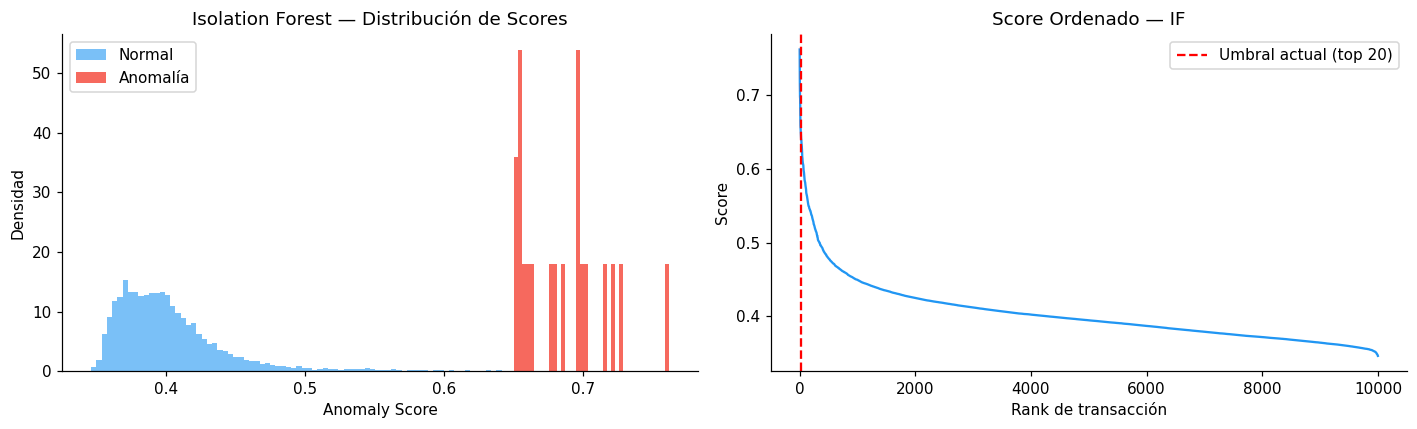

In [116]:
# Distribución de scores
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(if_scores[if_labels == 0], bins=80, alpha=0.6,
        color="#2196F3", label="Normal", density=True)
ax.hist(if_scores[if_labels == 1], bins=40, alpha=0.8,
        color="#F44336", label="Anomalía", density=True)
ax.set_xlabel("Anomaly Score")
ax.set_ylabel("Densidad")
ax.set_title("Isolation Forest — Distribución de Scores")
ax.legend()

ax = axes[1]
sorted_scores = np.sort(if_scores)[::-1]
ax.plot(sorted_scores, color="#2196F3", lw=1.5)
ax.axvline(if_labels.sum(), color="red", ls="--", lw=1.5,
           label=f"Umbral actual (top {if_labels.sum():,})")
ax.set_xlabel("Rank de transacción")
ax.set_ylabel("Score")
ax.set_title("Score Ordenado — IF")
ax.legend()

plt.tight_layout()
plt.show()


La distribución de scores muestra una separación visible entre transacciones
normales y anómalas: los scores de las anomalías detectadas se concentran
en valores más altos, confirmando que el modelo logra discriminar entre ambos
grupos.

Isolation Forest — Métricas de evaluación:
  Precision : 0.2500  (25.0% de las alertas son fraude real)
  Recall    : 0.3846  (38.5% de los fraudes reales fueron detectados)
  F1-Score  : 0.3030
  ROC-AUC   : 0.9712


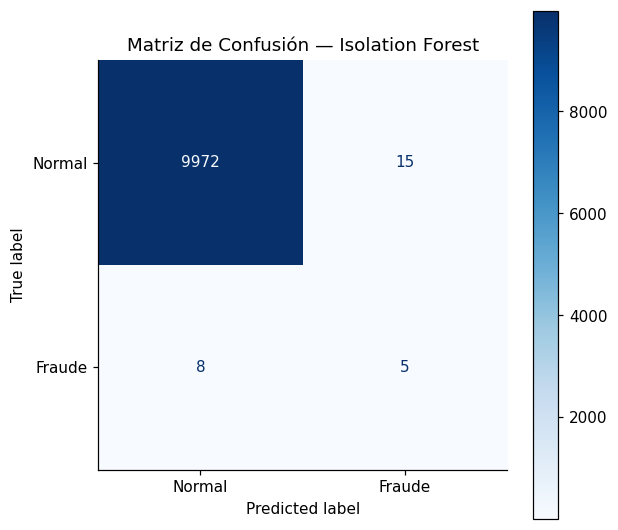

In [117]:
# Evaluación contra etiquetas reales
p_if  = precision_score(labels_sample, if_labels)
r_if  = recall_score(labels_sample, if_labels)
f1_if = f1_score(labels_sample, if_labels)
auc_if = roc_auc_score(labels_sample, if_scores)

print("Isolation Forest — Métricas de evaluación:")
print(f"  Precision : {p_if:.4f}  ({p_if*100:.1f}% de las alertas son fraude real)")
print(f"  Recall    : {r_if:.4f}  ({r_if*100:.1f}% de los fraudes reales fueron detectados)")
print(f"  F1-Score  : {f1_if:.4f}")
print(f"  ROC-AUC   : {auc_if:.4f}")


# Matriz de confusión
cm = confusion_matrix(labels_sample, if_labels, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[ "Normal", "Fraude"]) # Assuming 0 is Normal, 1 is Fraud
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title("Matriz de Confusión — Isolation Forest")
plt.grid(False)
plt.show()

El ROC-AUC mide la capacidad del modelo para rankear correctamente las
transacciones fraudulentas por encima de las legítimas, independientemente
del umbral. El valor obtenido de 0.97 indica una excelente capacidad discriminativa.

El Recall indica qué fracción de los fraudes reales fueron detectados. En nuestro caso obtuvimos un valor de 0.38, esto significa que muchos fraudes pasan desapercibidos.
La Precision, en cambio, refleja cuántas de las alertas generadas son fraudes
reales. El valor de 0.25 es bajo, lo que implica muchos falsos positivos y mayor carga operativa para el equipo de revisión manual.

Estas ultimas métricas miden el rendimiento con el umbral actual, por lo que el problema no es que el modelo no discrimine, sino que puede que el umbral está mal calibrado para este dataset.

---

## 4. Local Outlier Factor (LOF)

LOF detecta anomalías comparando la **densidad local** de cada punto con la
de sus vecinos. Un punto es anómalo si está en una región de menor densidad
que sus vecinos más cercanos: su distancia promedio a ellos es mucho mayor
que las distancias internas del vecindario.

A diferencia de Isolation Forest, LOF es **sensible a la estructura local**
del espacio: puede detectar anomalías en regiones densas donde IF fallaría,
pero también puede confundirse en bordes de clusters legítimos.

Parámetros clave:
- `n_neighbors=20`: número de vecinos para estimar la densidad local.
  Valores pequeños hacen el modelo sensible a ruido local; valores grandes
  lo hacen más global y menos sensible a anomalías locales.
- `contamination=0.002`: igual que en IF, fija el umbral de clasificación.
- `algorithm='ball_tree'`: estructura de índice espacial que acelera
  la búsqueda de vecinos de O(n²) a O(n log n) en la práctica.

>Limitación de escala: LOF tiene complejidad O(n²) sin aproximaciones: calcula distancias entre todos los pares de puntos. Sobre 284.807 transacciones esto es computacionalmente prohibitivo. Por eso se entrena sobre la muestra de 30.000, lo cual ya representa una reducción de ~10x respecto al dataset completo.

In [69]:
t0 = time.time()
lof = LocalOutlierFactor(
    n_neighbors=50,
    contamination=0.002,
    novelty=False,
    n_jobs=-1,
    algorithm="ball_tree",
)
lof_pred = lof.fit_predict(X_sample)
t_fit_lof = time.time() - t0

lof_scores = -lof.negative_outlier_factor_
lof_labels = (lof_pred == -1).astype(int)

print(f"Tiempo de entrenamiento LOF : {t_fit_lof:.2f} s")
print(f"Anomalías detectadas        : {lof_labels.sum():,}  ({lof_labels.mean()*100:.3f} %)")


Tiempo de entrenamiento LOF : 9.38 s
Anomalías detectadas        : 20  (0.200 %)


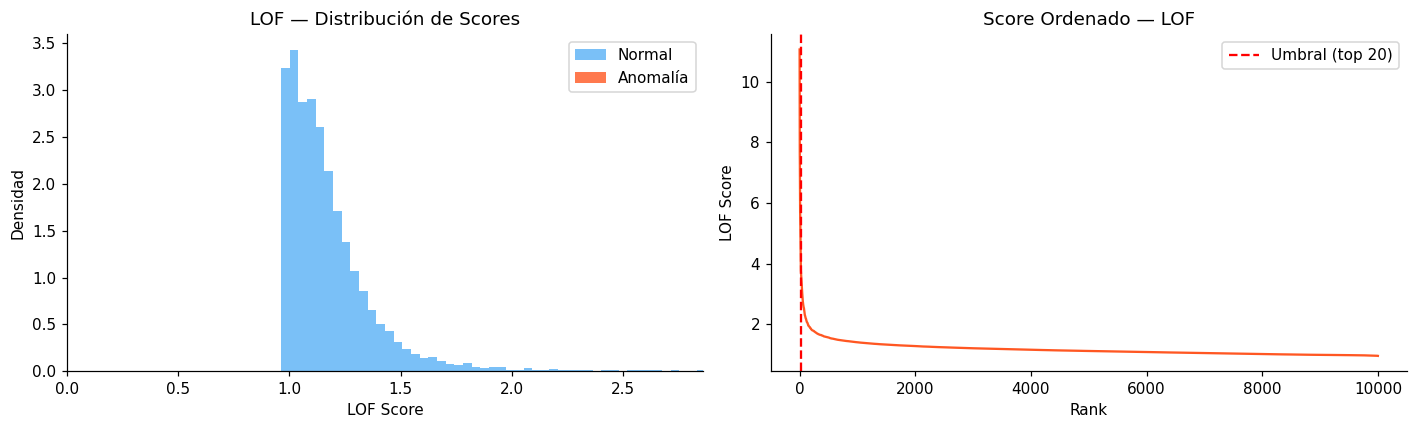

In [78]:
# Distribución de scores LOF
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(lof_scores[lof_labels == 0], bins=80, alpha=0.6,
        color="#2196F3", label="Normal", density=True)
ax.hist(lof_scores[lof_labels == 1], bins=40, alpha=0.8,
        color="#FF5722", label="Anomalía", density=True)
ax.set_xlabel("LOF Score")
ax.set_ylabel("Densidad")
ax.set_title("LOF — Distribución de Scores")
ax.set_xlim(0, np.percentile(lof_scores, 99.5))
ax.legend()

ax = axes[1]
sorted_lof = np.sort(lof_scores)[::-1]
ax.plot(sorted_lof, color="#FF5722", lw=1.5)
ax.axvline(lof_labels.sum(), color="red", ls="--", lw=1.5,
           label=f"Umbral (top {lof_labels.sum():,})")
ax.set_xlabel("Rank")
ax.set_ylabel("LOF Score")
ax.set_title("Score Ordenado — LOF")
ax.legend()

plt.tight_layout()
plt.show()


LOF — Métricas de evaluación:
  Precision : 0.3500  (35.0% de las alertas son fraude real)
  Recall    : 0.5000  (50.0% de los fraudes reales fueron detectados)
  F1-Score  : 0.4118
  ROC-AUC   : 0.9917


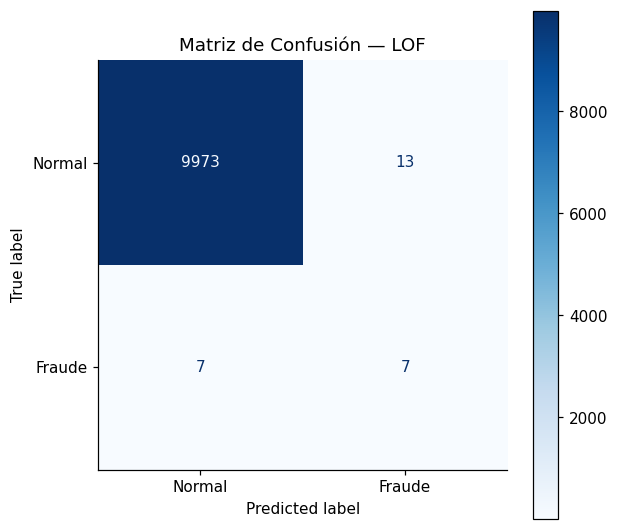

In [79]:
# Evaluación
p_lof  = precision_score(labels_sample, lof_labels)
r_lof  = recall_score(labels_sample, lof_labels)
f1_lof = f1_score(labels_sample, lof_labels)
auc_lof = roc_auc_score(labels_sample, lof_scores)

print("LOF — Métricas de evaluación:")
print(f"  Precision : {p_lof:.4f}  ({p_lof*100:.1f}% de las alertas son fraude real)")
print(f"  Recall    : {r_lof:.4f}  ({r_lof*100:.1f}% de los fraudes reales fueron detectados)")
print(f"  F1-Score  : {f1_lof:.4f}")
print(f"  ROC-AUC   : {auc_lof:.4f}")

# Matriz de confusión
cm_lof = confusion_matrix(labels_sample, lof_labels, labels=[0, 1])
disp_lof = ConfusionMatrixDisplay(confusion_matrix=cm_lof, display_labels=[ "Normal", "Fraude"]) # Assuming 0 is Normal, 1 is Fraud
fig, ax = plt.subplots(figsize=(6, 6))
disp_lof.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title("Matriz de Confusión — LOF")
plt.grid(False)
plt.show()

Al igual que Isolation Forest, obtuvimos un valor de ROC-AUC de casi perfecto, y vemos el problema del umbral en Recall y Precision.

El tiempo de entrenamiento es notablemente mayor que el de Isolation Forest
sobre la misma muestra, lo que confirma su inviabilidad para predicción
en tiempo real. Su rol en producción sería como validación nocturna sobre
lotes de transacciones ya procesadas.

---

## 5. Reconstrucción por PCA

Este enfoque usa PCA no para reducir dimensionalidad, sino como **modelo
de comportamiento normal**. La idea es:

1. Entrenar un PCA con k componentes que capturen la mayor parte de la varianza.
2. Reconstruir cada transacción proyectándola al espacio reducido y volviendo
   al espacio original.
3. Medir el **error de reconstrucción** (MSE por fila) entre la transacción
   original y su reconstrucción.

Una transacción normal se reconstruye bien porque su varianza está capturada
por los primeros componentes. Una transacción fraudulenta, cuyo patrón es
infrecuente, tiene alta varianza en los últimos componentes (los descartados)
y por lo tanto se reconstruye con mayor error.

Elección del número de componentes:  
Se usa el número de componentes que explican el 95% de la varianza. Usar menos componentes aumenta la sensibilidad del modelo (más anomalías detectadas) pero también los falsos positivos. Usar más componentes reduce el error de reconstrucción de todos los puntos y pierde capacidad discriminativa.

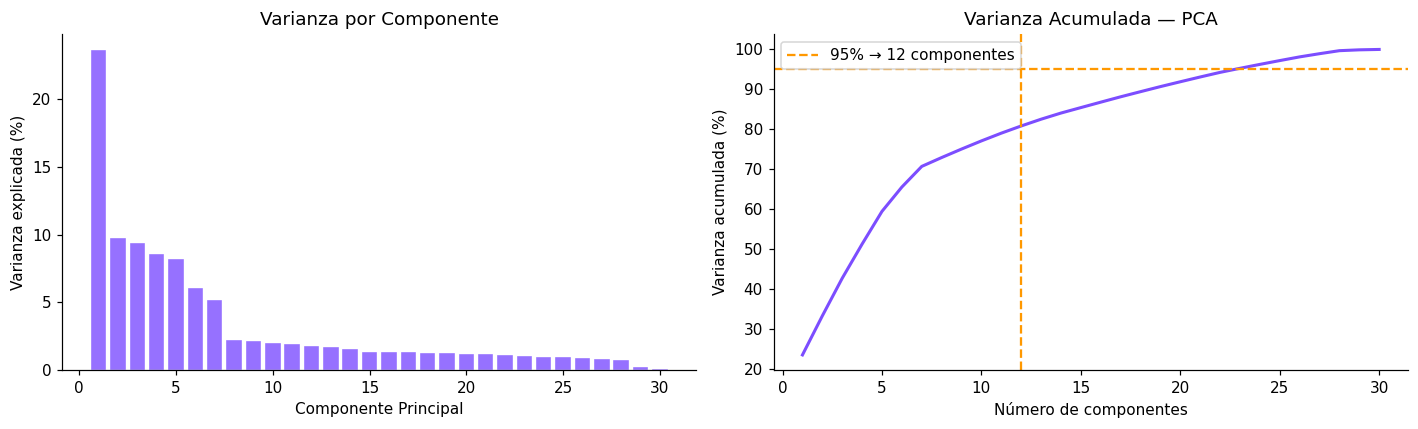

Componentes para 95% de varianza: 12 de 30 features


In [100]:
# Varianza explicada
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_sample)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.searchsorted(cumvar, 0.90) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
       pca_full.explained_variance_ratio_ * 100,
       color="#7C4DFF", alpha=0.8, edgecolor="white", linewidth=0.3)
ax.set_xlabel("Componente Principal")
ax.set_ylabel("Varianza explicada (%)")
ax.set_title("Varianza por Componente")

ax = axes[1]
ax.plot(range(1, len(cumvar) + 1), cumvar * 100, color="#7C4DFF", lw=2)
ax.axhline(90, ls="--", color="#FF9800", lw=1.5, label=f"90% → {n_90} componentes")
ax.axvline(n_90, ls="--", color="#FF9800", lw=1.5)
ax.set_xlabel("Número de componentes")
ax.set_ylabel("Varianza acumulada (%)")
ax.set_title("Varianza Acumulada — PCA")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Componentes para 90% de varianza: {n_90} de {X_sample.shape[1]} features")


Umbral de error (p99.8) : 4.366441
Anomalías detectadas    : 20  (0.200 %)


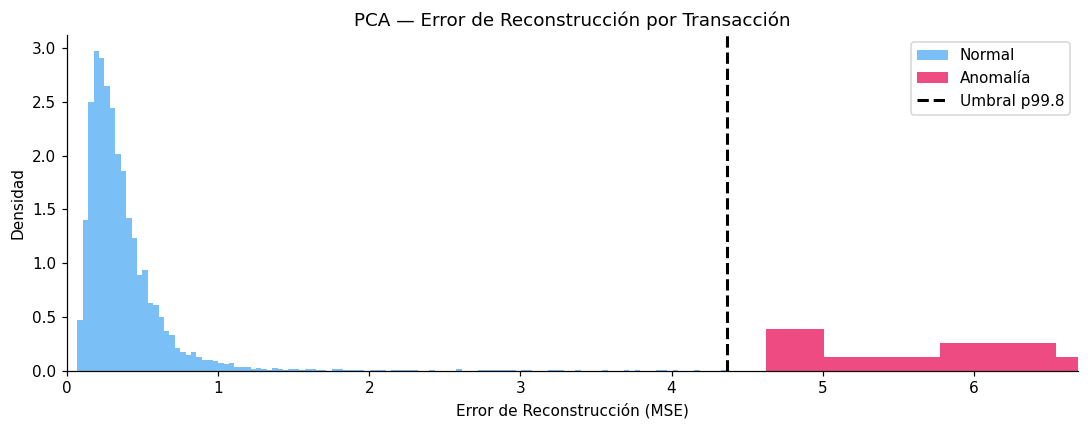

In [101]:
# Error de reconstrucción
pca_model = PCA(n_components=n_90, random_state=RANDOM_STATE)
X_reduced      = pca_model.fit_transform(X_sample)
X_reconstructed = pca_model.inverse_transform(X_reduced)

pca_recon_error = np.mean((X_sample - X_reconstructed) ** 2, axis=1)

# Umbral en el percentil 99.8 (~0.2% de anomalías esperadas)
pca_threshold = np.percentile(pca_recon_error, 99.8)
pca_labels = (pca_recon_error > pca_threshold).astype(int)

print(f"Umbral de error (p99.8) : {pca_threshold:.6f}")
print(f"Anomalías detectadas    : {pca_labels.sum():,}  ({pca_labels.mean()*100:.3f} %)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(pca_recon_error[pca_labels == 0], bins=120,
        color="#2196F3", alpha=0.6, label="Normal", density=True)
ax.hist(pca_recon_error[pca_labels == 1], bins=40,
        color="#E91E63", alpha=0.8, label="Anomalía", density=True)
ax.axvline(pca_threshold, color="black", ls="--", lw=2, label="Umbral p99.8")
ax.set_xlabel("Error de Reconstrucción (MSE)")
ax.set_ylabel("Densidad")
ax.set_title("PCA — Error de Reconstrucción por Transacción")
ax.set_xlim(0, np.percentile(pca_recon_error, 99.9))
ax.legend()
plt.tight_layout()
plt.show()


PCA Reconstruction — Métricas de evaluación:
  Precision : 0.3000  (30.0% de las alertas son fraude real)
  Recall    : 0.4615  (46.2% de los fraudes reales fueron detectados)
  F1-Score  : 0.3636
  ROC-AUC   : 0.9513


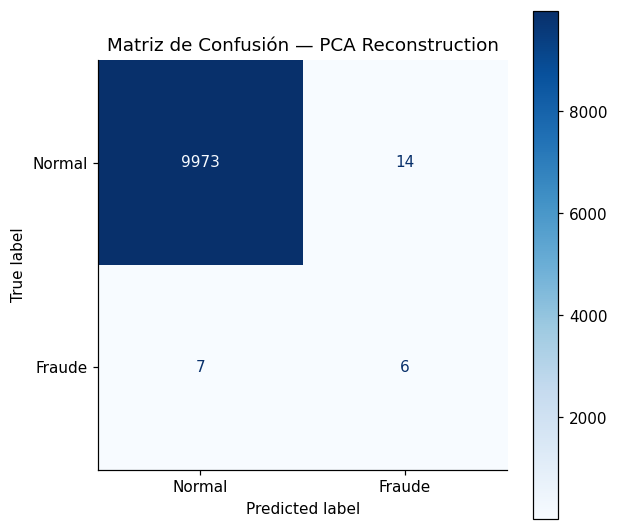

In [102]:
# Evaluación
p_pca  = precision_score(labels_sample, pca_labels)
r_pca  = recall_score(labels_sample, pca_labels)
f1_pca = f1_score(labels_sample, pca_labels)
auc_pca = roc_auc_score(labels_sample, pca_recon_error)

print("PCA Reconstruction — Métricas de evaluación:")
print(f"  Precision : {p_pca:.4f}  ({p_pca*100:.1f}% de las alertas son fraude real)")
print(f"  Recall    : {r_pca:.4f}  ({r_pca*100:.1f}% de los fraudes reales fueron detectados)")
print(f"  F1-Score  : {f1_pca:.4f}")
print(f"  ROC-AUC   : {auc_pca:.4f}")

# Matriz de confusión
cm_pca = confusion_matrix(labels_sample, pca_labels, labels=[0, 1])
disp_pca = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=[ "Normal", "Fraude"]) # Assuming 0 is Normal, 1 is Fraud
fig, ax = plt.subplots(figsize=(6, 6))
disp_pca.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title("Matriz de Confusión — PCA Reconstruction")
plt.grid(False)
plt.show()

El error de reconstrucción separa visualmente dos poblaciones: la mayoría
de las transacciones tienen errores bajos y concentrados, mientras que
un grupo pequeño acumula errores notablemente más altos. Esto es exactamente
lo que el modelo busca: los patrones fraudulentos no están bien representados
por los primeros componentes principales del comportamiento normal y por lo
tanto se reconstruyen con mayor error.

La elección del umbral en el percentil 99.8 es coherente con la tasa
de fraude esperada del 0,2%, pero es una decisión que puede ajustarse
según la relación de costos del negocio, como se analiza en la sección
de curva de costos.

---

## 6. Comparación entre métodos

Cada método parte de un supuesto diferente sobre qué hace a una transacción
anómala. Que los tres coincidan en marcar la misma transacción es evidencia
mucho más sólida de fraude que si solo uno lo hace. Una discrepancia no
invalida ninguno de los modelos: indica que la transacción es anómala
según cierto criterio pero no según otros, lo que puede orientar la
investigación manual.

In [123]:
# Tabla comparativa de métricas
results = pd.DataFrame({
    "Método": ["Isolation Forest", "LOF", "PCA Error"],
    "Precision": [p_if, p_lof, p_pca],
    "Recall":    [r_if, r_lof, r_pca],
    "F1-Score":  [f1_if, f1_lof, f1_pca],
    "ROC-AUC":   [auc_if, auc_lof, auc_pca],
    "Anomalías detectadas": [if_labels.sum(), lof_labels.sum(), pca_labels.sum()],
}).set_index("Método")

display(results.round(4))


,Precision,Recall,F1-Score,ROC-AUC,Anomalías detectadas
Método,,,,,
Isolation Forest,0.25,0.3846,0.3030,0.9712,20
LOF,0.35,0.5000,0.4118,0.9917,20
PCA Error,0.30,0.4615,0.3636,0.9513,20


In [124]:
# Superposición entre métodos
sets = {
    "IF":  set(np.where(if_labels)[0]),
    "LOF": set(np.where(lof_labels)[0]),
    "PCA": set(np.where(pca_labels)[0]),
}

only_IF  = len(sets["IF"]  - sets["LOF"] - sets["PCA"])
only_LOF = len(sets["LOF"] - sets["IF"]  - sets["PCA"])
only_PCA = len(sets["PCA"] - sets["IF"]  - sets["LOF"])
IF_LOF   = len((sets["IF"] & sets["LOF"]) - sets["PCA"])
IF_PCA   = len((sets["IF"] & sets["PCA"]) - sets["LOF"])
LOF_PCA  = len((sets["LOF"] & sets["PCA"]) - sets["IF"])
ALL      = len(sets["IF"] & sets["LOF"] & sets["PCA"])

print("Superposición entre métodos:")
print(f"  Solo IF            : {only_IF:>5,}")
print(f"  Solo LOF           : {only_LOF:>5,}")
print(f"  Solo PCA           : {only_PCA:>5,}")
print(f"  IF ∩ LOF  (no PCA) : {IF_LOF:>5,}")
print(f"  IF ∩ PCA  (no LOF) : {IF_PCA:>5,}")
print(f"  LOF ∩ PCA (no IF)  : {LOF_PCA:>5,}")
print(f"  IF ∩ LOF ∩ PCA     : {ALL:>5,}  ← anomalías robustas")

# Etiqueta de consenso
votes     = if_labels + lof_labels + pca_labels
consensus = (votes >= 2).astype(int)
p_cons  = precision_score(labels_sample, consensus)
r_cons  = recall_score(labels_sample, consensus)
f1_cons = f1_score(labels_sample, consensus)
print(f"\nConsenso (≥2 métodos): {consensus.sum():,} alertas")
print(f"  Precision: {p_cons:.4f}  |  Recall: {r_cons:.4f}  |  F1: {f1_cons:.4f}")


Superposición entre métodos:
  Solo IF            :     8
  Solo LOF           :    20
  Solo PCA           :     8
  IF ∩ LOF  (no PCA) :     0
  IF ∩ PCA  (no LOF) :    12
  LOF ∩ PCA (no IF)  :     0
  IF ∩ LOF ∩ PCA     :     0  ← anomalías robustas

Consenso (≥2 métodos): 12 alertas
  Precision: 0.4167  |  Recall: 0.3846  |  F1: 0.4000


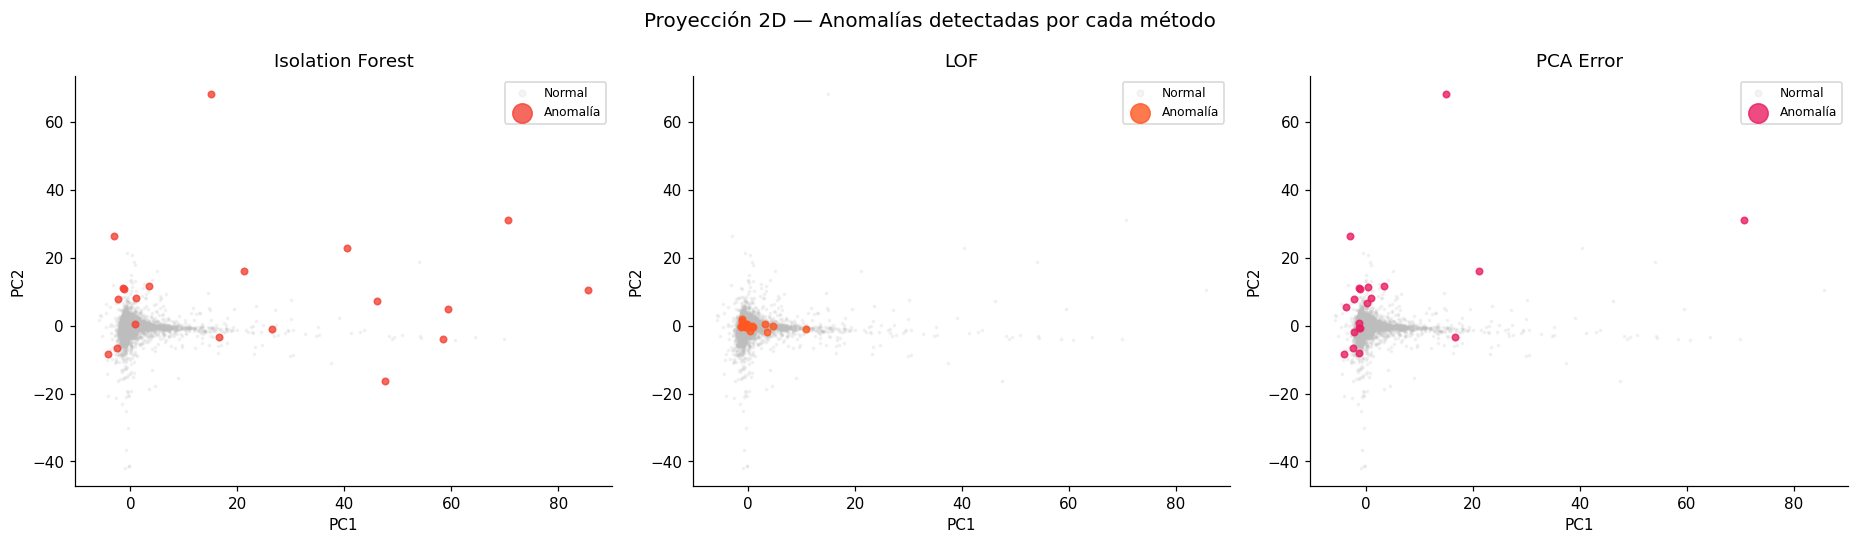

In [125]:
# Visualización 2D coloreada por cada método
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_sample)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
configs = [
    ("Isolation Forest", if_labels,  "#F44336"),
    ("LOF",              lof_labels, "#FF5722"),
    ("PCA Error",        pca_labels, "#E91E63"),
]

for ax, (title, lbl, color) in zip(axes, configs):
    ax.scatter(X_2d[lbl == 0, 0], X_2d[lbl == 0, 1],
               s=2, alpha=0.15, color="#BDBDBD", label="Normal")
    ax.scatter(X_2d[lbl == 1, 0], X_2d[lbl == 1, 1],
               s=18, alpha=0.8, color=color, label="Anomalía")
    ax.set_title(title)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(markerscale=3, fontsize=8)

plt.suptitle("Proyección 2D — Anomalías detectadas por cada método", fontsize=13)
plt.tight_layout()
plt.show()


Que LOF no comparta ninguna detección con IF ni PCA significa que están encontrando tipos distintos de fraude. Si vemos las proyecciones teniendo esto en cuenta podemos observar que:
- IF y PCA coinciden en 12: detectan anomalías globales, transacciones que se alejan del comportamiento general. Son los fraudes más obvios.
- LOF detecta 20 distintas: detecta anomalías locales, transacciones que parecen normales globalmente pero rompen el patrón de su vecindario inmediato. Son fraudes más sofisticados.

El consenso de ≥2 métodos captura solo las 12 globales y descarta todo lo que LOF aporta, por eso el Recall no mejora. Una estrategia más útil sería tratar las detecciones de LOF como una lista de prioridad secundaria para revisión manual, en lugar de descartarlas por no tener consenso.

---

## 7. Análisis de clústeres

Antes de concluir sobre la estructura del fraude, es útil entender si
el comportamiento **normal** forma una masa homogénea o si existen
subpoblaciones diferenciadas. Esto tiene implicancias directas:

- Si el comportamiento normal es homogéneo, un único modelo global es suficiente.
- Si hay subpoblaciones, cada una tiene su propio "normal" y un modelo global
  puede confundir transacciones de una subpoblación poco frecuente con fraude.

Se aplica K-Means sobre las transacciones clasificadas como normales por
el consenso de los tres métodos, usando el método del codo y el Silhouette
Score para elegir el número de clústeres.

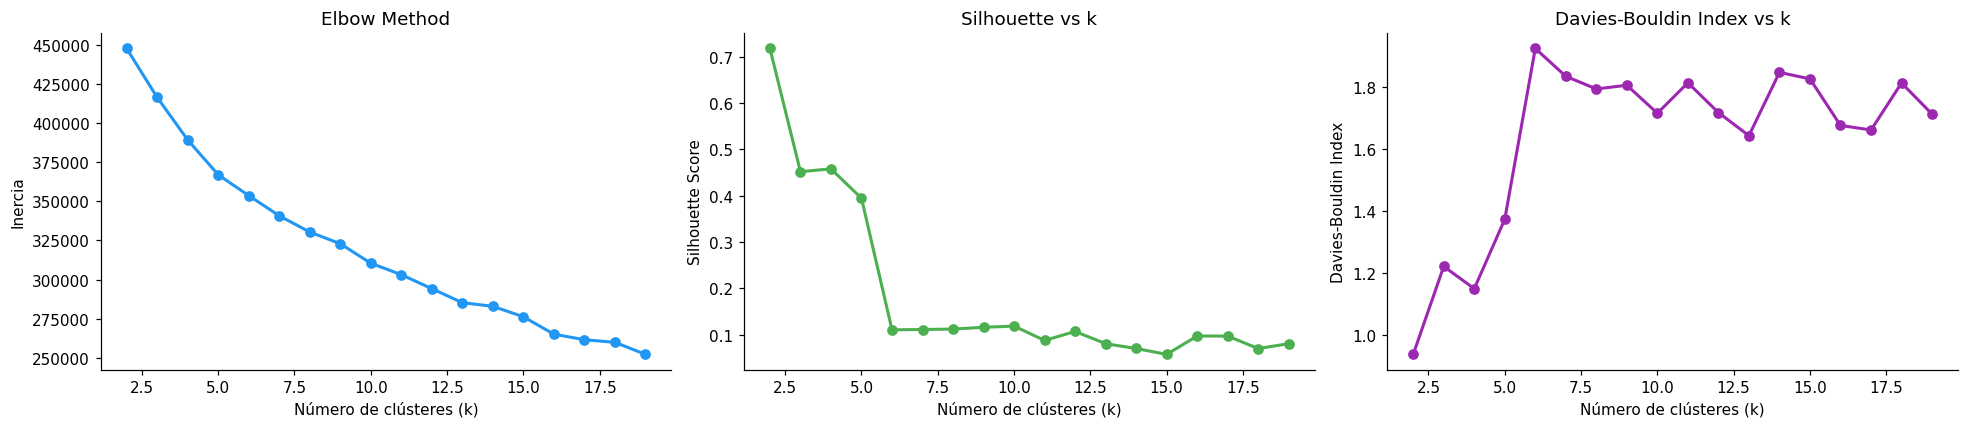

Mejor k según Silhouette: 2  (score: 0.7180)
Mejor k según Davies-Bouldin: 2  (score: 0.9386)


In [132]:
# Solo transacciones normales según consenso
normal_idx = np.where(consensus == 0)[0]
X_normal = X_sample[normal_idx]

inertias = []
silhouettes = []
davies_bouldin_scores = []
K_range = range(2, 20)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_normal)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_normal, km.labels_, sample_size=5000,
                           random_state=RANDOM_STATE)
    silhouettes.append(sil)
    db_score = davies_bouldin_score(X_normal, km.labels_)
    davies_bouldin_scores.append(db_score)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

ax = axes[0]
ax.plot(K_range, inertias, "o-", color="#2196F3", lw=2)
ax.set_xlabel("Número de clústeres (k)")
ax.set_ylabel("Inercia")
ax.set_title("Elbow Method")

ax = axes[1]
ax.plot(K_range, silhouettes, "o-", color="#4CAF50", lw=2)
ax.set_xlabel("Número de clústeres (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette vs k")

ax = axes[2]
ax.plot(K_range, davies_bouldin_scores, "o-", color="#9C27B0", lw=2)
ax.set_xlabel("Número de clústeres (k)")
ax.set_ylabel("Davies-Bouldin Index")
ax.set_title("Davies-Bouldin Index vs k")

plt.tight_layout()
plt.show()

best_k_silhouette = list(K_range)[np.argmax(silhouettes)]
best_k_db = list(K_range)[np.argmin(davies_bouldin_scores)]
print(f"Mejor k según Silhouette: {best_k_silhouette}  (score: {max(silhouettes):.4f})")
print(f"Mejor k según Davies-Bouldin: {best_k_db}  (score: {min(davies_bouldin_scores):.4f})")

Los tres indicadores coinciden en k=2 como mejor opción. Pero lo más importante no es el k óptimo sino los valores absolutos:
- El Elbow no tiene codo claro: la inercia baja de forma suave y continua sin un quiebre pronunciado. Esto indica que los datos no tienen una estructura de clusters natural bien definida.
- Silhouette = 0.718 para k=2 y cae dramáticamente a ~0.1 para k≥3. Eso significa que con más de 2 clusters los grupos están completamente solapados y no tienen sentido.
- Davies-Bouldin sube desde k=5: valores más altos son peores, confirma que más clusters empeoran la separación.

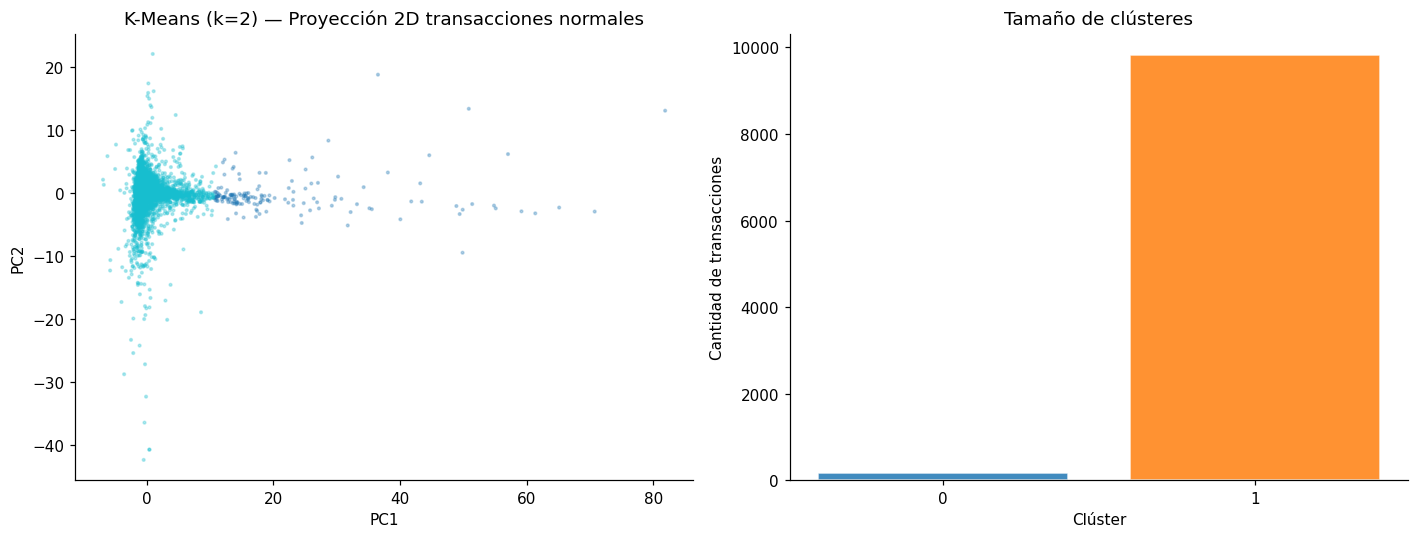

Distribución de transacciones normales por clúster:
0     161
1    9827


In [134]:
# Clústeres finales
km_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
km_final.fit(X_normal)

pca_2d_km = PCA(n_components=2, random_state=RANDOM_STATE)
X_normal_2d = pca_2d_km.fit_transform(X_normal)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
scatter = ax.scatter(X_normal_2d[:, 0], X_normal_2d[:, 1],
                     c=km_final.labels_, cmap="tab10", s=3, alpha=0.3)
ax.set_title(f"K-Means (k={best_k}) — Proyección 2D transacciones normales")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

ax = axes[1]
cluster_sizes = pd.Series(km_final.labels_).value_counts().sort_index()
ax.bar(cluster_sizes.index.astype(str), cluster_sizes.values,
       color=plt.cm.tab10.colors[:best_k], alpha=0.85, edgecolor="white")
ax.set_xlabel("Clúster"); ax.set_ylabel("Cantidad de transacciones")
ax.set_title("Tamaño de clústeres")

plt.tight_layout()
plt.show()

print("Distribución de transacciones normales por clúster:")
print(cluster_sizes.to_string())


El clustering encontró un cluster de 9.827 transacciones y otro de 161.
Mirando la proyección 2D, los puntos del cluster mas pequeño son los que están dispersos lejos del núcleo central, con valores extremos en PC1 (hasta 80) y PC2 (hasta -40). Es decir, K-Means no encontró dos tipos de comportamiento normal, sino que separó el núcleo compacto de los puntos dispersos en las colas.

Entonces, podemos decir que el comportamiento normal en este dataset es esencialmente homogéneo. No hay subpoblaciones diferenciadas de usuarios legítimos.  
Esto implica que el fraude tampoco forma clusters compactos: se distribuye de forma dispersa y heterogénea en el espacio de features, lo que explica por qué los modelos basados en densidad como LOF detectan anomalías distintas a los basados en aislamiento como IF. No hay un único "perfil de fraude" sino múltiples formas de manifestarse.

---

## 8. Umbral óptimo y curva de costos

Hasta ahora todos los modelos usaron `contamination=0.002` como umbral, el cual determina cuántas transacciones se retienen para revisión manual y cuántos fraudes pasan desapercibidos.

Esto nos lleva a concebir este umbral como una desición de negocio, cada error tiene un costo distinto:

- Falso Positivo (FP): se retiene una transacción legítima.
  Costo: fricción con el cliente, posible abandono, costo de revisión manual.
- Falso Negativo (FN): un fraude pasa sin ser detectado.
  Costo: reembolso del monto, costos de disputa, daño reputacional.

La relación C_FN / C_FP determina cuán agresivo debe ser el sistema.
Se analizan tres escenarios representativos.

Conservador  (C_FN/C_FP = 5:1):
  Umbral óptimo: 0.6541 | Flaggeadas: 0.150% | Costo mínimo: 50

Moderado     (C_FN/C_FP = 20:1):
  Umbral óptimo: 0.6054 | Flaggeadas: 0.600% | Costo mínimo: 131

Agresivo     (C_FN/C_FP = 100:1):
  Umbral óptimo: 0.5333 | Flaggeadas: 2.200% | Costo mínimo: 409



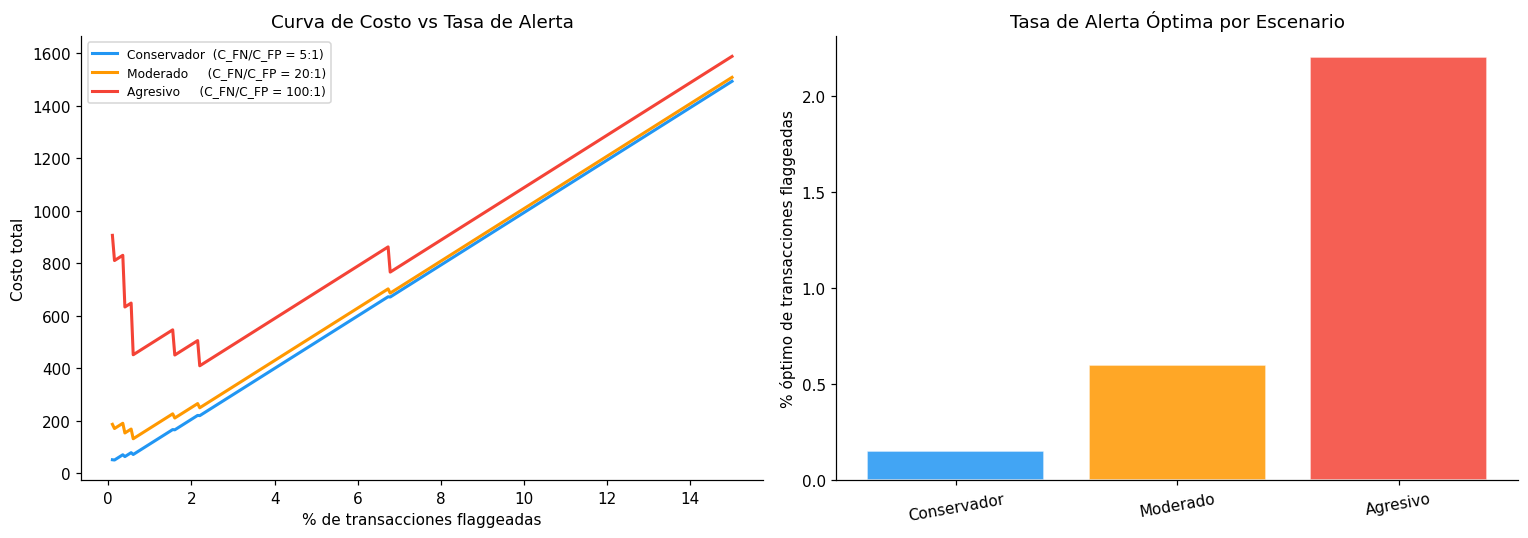

In [135]:
# Curva de costos usando scores de Isolation Forest como ranking
scenarios = {
    "Conservador  (C_FN/C_FP = 5:1)":  {"CFN": 5,   "CFP": 1},
    "Moderado     (C_FN/C_FP = 20:1)": {"CFN": 20,  "CFP": 1},
    "Agresivo     (C_FN/C_FP = 100:1)":{"CFN": 100, "CFP": 1},
}

total_anom = labels_sample.sum()
thresholds = np.percentile(if_scores, np.linspace(99.9, 85, 300))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_sc = ["#2196F3", "#FF9800", "#F44336"]

opt_flags = []
for (label, params), color in zip(scenarios.items(), colors_sc):
    CFN, CFP = params["CFN"], params["CFP"]
    costs, flag_rates = [], []
    for thr in thresholds:
        flagged = (if_scores >= thr)
        tp = (flagged & (labels_sample == 1)).sum()
        fp = (flagged & (labels_sample == 0)).sum()
        fn = total_anom - tp
        costs.append(CFN * fn + CFP * fp)
        flag_rates.append(flagged.mean() * 100)
    axes[0].plot(flag_rates, costs, lw=2, color=color, label=label)
    opt_idx = np.argmin(costs)
    opt_flags.append(flag_rates[opt_idx])
    print(f"{label.strip()}:")
    print(f"  Umbral óptimo: {thresholds[opt_idx]:.4f} | Flaggeadas: {flag_rates[opt_idx]:.3f}% | Costo mínimo: {min(costs):,.0f}")
    print()

axes[0].set_xlabel("% de transacciones flaggeadas")
axes[0].set_ylabel("Costo total")
axes[0].set_title("Curva de Costo vs Tasa de Alerta")
axes[0].legend(fontsize=8)

axes[1].bar([s.split("(")[0].strip() for s in scenarios],
            opt_flags, color=colors_sc, alpha=0.85, edgecolor="white")
axes[1].set_ylabel("% óptimo de transacciones flaggeadas")
axes[1].set_title("Tasa de Alerta Óptima por Escenario")
axes[1].tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.show()


En estos graficos podemos ver distintos escenarios de costos, donde el mínimo de cada curva indica cuántas transacciones conviene flaggear (marcar como sospechosas) para minimizar el costo total bajo ese escenario.

Al principio, flaggear mas transacciones reduce el costo porque se capturan fraudes que de otra forma pasarían desapercibidos. En algún punto el beneficio de capturar más fraudes se equilibra con el costo de retener más transacciones legítimas. A partir de ahí capturar mas transacciones solo agrega FP sin reducir suficientemente los FN, y el costo total sube.
El mínimo de la curva es ese punto de equilibrio.

La decisión clave para el negocio es estimar la relación C_FN/C_FP con datos reales. El monto promedio de fraude, el costo de disputa, el costo de soporte por falsa alarma y la probabilidad de churn del cliente son los insumos necesarios para ubicarse en uno de estos tres escenarios y calibrar el umbral de producción.

---

## 9. Análisis temporal de anomalías

La variable Time registra los segundos desde la primera transacción del dataset.
Si los fraudes se concentran en ciertas franjas horarias, eso tiene
implicancias directas para el diseño del sistema de detección en producción:
un umbral fijo global no es equivalente a uno que tenga en cuenta el
contexto temporal de cada transacción.

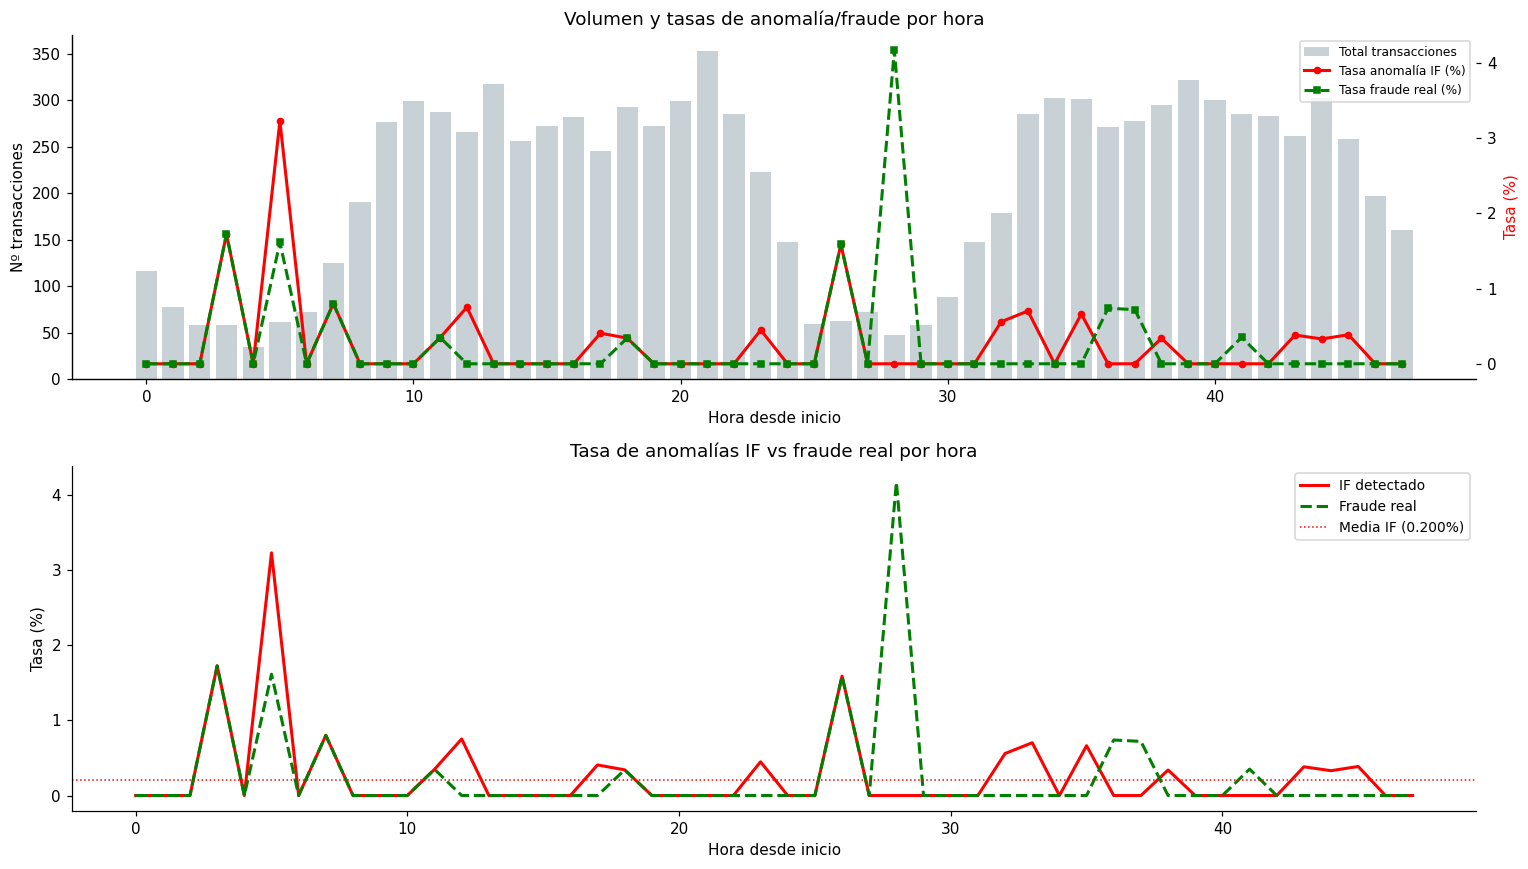

Test KS — distribución temporal fraudes vs normales:
  KS stat : 0.2022
  p-value : 5.9382e-01
  → Sin diferencia temporal significativa


In [136]:
df_temp = pd.DataFrame({
    "anomaly_IF":   if_labels,
    "anomaly_cons": consensus,
    "Time":         df_fraude["Time"].values[sample_idx],
    "true_label":   labels_sample,
})
df_temp["time_hour"] = (df_temp["Time"] / 3600).astype(int)

hourly = df_temp.groupby("time_hour").agg(
    n_total      = ("anomaly_IF", "count"),
    n_anom_IF    = ("anomaly_IF", "sum"),
    n_fraude_real= ("true_label", "sum"),
).reset_index()
hourly["rate_IF"]    = hourly["n_anom_IF"]     / hourly["n_total"]
hourly["rate_real"]  = hourly["n_fraude_real"] / hourly["n_total"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.bar(hourly["time_hour"], hourly["n_total"],
       color="#B0BEC5", alpha=0.7, label="Total transacciones")
ax2 = ax.twinx()
ax2.plot(hourly["time_hour"], hourly["rate_IF"] * 100,
         "r-o", ms=4, lw=2, label="Tasa anomalía IF (%)")
ax2.plot(hourly["time_hour"], hourly["rate_real"] * 100,
         "g--s", ms=4, lw=2, label="Tasa fraude real (%)")
ax2.set_ylabel("Tasa (%)", color="red")
ax.set_xlabel("Hora desde inicio")
ax.set_ylabel("Nº transacciones")
ax.set_title("Volumen y tasas de anomalía/fraude por hora")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")

ax = axes[1]
ax.plot(hourly["time_hour"], hourly["rate_IF"]   * 100,
        "r-", lw=2, label="IF detectado")
ax.plot(hourly["time_hour"], hourly["rate_real"] * 100,
        "g--", lw=2, label="Fraude real")
ax.axhline(if_labels.mean() * 100, color="r", ls=":", lw=1,
           label=f"Media IF ({if_labels.mean()*100:.3f}%)")
ax.set_xlabel("Hora desde inicio")
ax.set_ylabel("Tasa (%)")
ax.set_title("Tasa de anomalías IF vs fraude real por hora")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Test KS
times_anom   = df_temp.loc[df_temp["true_label"] == 1, "Time"].values
times_normal = df_temp.loc[df_temp["true_label"] == 0, "Time"].values
ks_stat, ks_p = ks_2samp(times_anom, times_normal)
print(f"Test KS — distribución temporal fraudes vs normales:")
print(f"  KS stat : {ks_stat:.4f}")
print(f"  p-value : {ks_p:.4e}")
print(f"  → {'Distribuciones temporales DISTINTAS (p < 0.05)' if ks_p < 0.05 else 'Sin diferencia temporal significativa'}")


El gráfico compara hora a hora la tasa de anomalías que detecta IF (rojo) contra la tasa de fraude real (verde). Si el modelo fuera perfecto, ambas líneas deberían moverse juntas.

Podemos notar un pico verde en la hora 27 (tasa ~4%), en esa hora hay una concentración muy alta de fraudes reales, pero IF apenas lo detecta, ell modelo parece estar fallando completamente en esa franja. Esto sugiere que los fraudes de esa hora tienen un patrón que IF no reconoce como anómalo, probablemente porque son similares en score a transacciones legítimas.

Tambiense puede apreciar un pico rojo en la hora 2 (tasa ~3.2%), esto significa que IF genera muchas alertas en esa hora pero la tasa de fraude real es baja, probablemente relacionada con el bajo volumen de transacciones en la madrugada.